# Expectation Decider — Probability Analysis of Student Exam Performance

**Project:** Predicting whether a student passes a competitive mathematics exam, using probability theory.

**Dataset:** 200 students — `study_hours`, `attendance`, `group_discussion`, `previous_test_score`, `final_exam_pass`.

This notebook covers: Basics of Probability, Types of Events, Random Variables & Distributions, Venn Diagrams, Contingency Tables, Independence, and Bayes' Theorem.


## 0. Setup — Load Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

df = pd.read_csv('/Users/devjoshi/Downloads/200_Students_Dataset.csv')
df['student_id'] = range(1, len(df) + 1)
df.head(10)

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass,student_id
0,8,70,Yes,97,Pass,1
1,16,87,Yes,73,Pass,2
2,12,84,No,93,Pass,3
3,9,82,No,93,Pass,4
4,8,90,No,42,Fail,5
5,20,89,No,98,Pass,6
6,12,94,No,89,Pass,7
7,12,66,No,51,Fail,8
8,5,75,No,40,Fail,9
9,9,85,No,93,Pass,10


In [2]:
df.describe()

,study_hours,attendance,previous_test_score,student_id
count,200.000000,200.00000,200.000000,200.000000
mean,10.265000,81.53500,70.755000,100.500000
std,5.495066,11.54405,18.064512,57.879185
min,2.000000,60.00000,40.000000,1.000000
25%,5.750000,72.75000,56.000000,50.750000
50%,10.000000,83.00000,69.000000,100.500000
75%,15.000000,92.00000,86.250000,150.250000
max,20.000000,100.00000,100.000000,200.000000


In [3]:
df['final_exam_pass'].value_counts()

final_exam_pass
Pass    157
Fail     43
Name: count, dtype: int64

## 1. Understanding the Basics

**What is Probability?**
Probability is a numerical measure (between 0 and 1) of how likely an event is to occur. A probability of 0 means the event is impossible, and 1 means it is certain. It is calculated as:

$$P(E) = \frac{\text{Number of favourable outcomes}}{\text{Total number of outcomes}}$$

**Key Probability Terminology**
- **Experiment**: A process with an uncertain outcome (e.g., picking a random student from the dataset).
- **Sample Space (S)**: The set of all possible outcomes (e.g., all 200 students).
- **Event (E)**: A subset of the sample space (e.g., "student passes the exam").
- **Random Variable**: A variable whose value is a numerical outcome of a random phenomenon.
- **Mutually Exclusive Events**: Events that cannot happen at the same time.
- **Independent Events**: Events where the occurrence of one does not affect the probability of the other.
- **Conditional Probability**: The probability of an event given that another event has already occurred.

**Three Probability Event Examples from the Dataset**
1. Event A: "A randomly selected student has attendance greater than 80%."
2. Event B: "A randomly selected student participated in group discussions (`group_discussion = Yes`)."
3. Event C: "A randomly selected student passed the final exam (`final_exam_pass = Pass`)."


In [4]:
# Quick numeric look at the three example events
p_A = (df['attendance'] > 80).mean()
p_B = (df['group_discussion'] == 'Yes').mean()
p_C = (df['final_exam_pass'] == 'Pass').mean()

print(f"P(Attendance > 80%)      = {p_A:.3f}")
print(f"P(Group Discussion = Yes) = {p_B:.3f}")
print(f"P(Final Exam = Pass)      = {p_C:.3f}")

P(Attendance > 80%)      = 0.590
P(Group Discussion = Yes) = 0.500
P(Final Exam = Pass)      = 0.785


## 2. Types of Events — Empirical vs Theoretical Probability

**Empirical probability** is calculated *from observed data* (relative frequency).
**Theoretical probability** is calculated from a known/assumed model, *before* looking at outcomes.

- **Empirical scenario**: "What is the probability that a student passes the exam?" — calculated directly from the 200 recorded outcomes.
- **Theoretical scenario**: "If we assume passing is like a fair coin toss decided independently for each of 3 students (p = 0.5 each), what is the probability that exactly 2 out of 3 pass?" — calculated using the Binomial formula *before* observing any data.


In [5]:
# Empirical probability (from actual data)
empirical_p_pass = (df['final_exam_pass'] == 'Pass').mean()
print(f"Empirical P(Pass) = {empirical_p_pass:.3f}")

# Theoretical probability (Binomial model, assumed p = 0.5, n = 3, k = 2)
from math import comb
n, k, p = 3, 2, 0.5
theoretical_p = comb(n, k) * (p**k) * ((1-p)**(n-k))
print(f"Theoretical P(exactly 2 of 3 pass | p=0.5) = {theoretical_p:.3f}")

Empirical P(Pass) = 0.785
Theoretical P(exactly 2 of 3 pass | p=0.5) = 0.375


## 3. Random Variable & Probability Distribution

**Random variable X** = "Number of students who pass the final exam, out of 3 randomly selected students."

X can take values 0, 1, 2, or 3.

We use the **empirical pass probability** from our dataset (p = P(Pass)) as the probability of success for each trial, and model X using the **Binomial Distribution**:

$$P(X=k) = \binom{3}{k} p^k (1-p)^{3-k}$$

*(Note: this assumes the 3 students are selected independently and with replacement, so the Binomial model applies.)*


In [6]:
from math import comb

p = empirical_p_pass         # probability a single student passes
n = 3

dist_table = pd.DataFrame({
    'X (num. passing)': [0, 1, 2, 3],
    'P(X=k)': [comb(n, k) * (p**k) * ((1-p)**(n-k)) for k in range(4)]
})
dist_table['P(X=k)'] = dist_table['P(X=k)'].round(4)
dist_table

,X (num. passing),P(X=k)
0,0,0.0099
1,1,0.1089
2,2,0.3975
3,3,0.4837


In [7]:
# Mean and Variance of the Binomial random variable
mean_X = n * p
var_X = n * p * (1 - p)

print(f"Mean  E(X) = n*p        = {mean_X:.3f}")
print(f"Variance Var(X) = n*p*(1-p) = {var_X:.3f}")

# Verify using the distribution table directly
mean_check = (dist_table['X (num. passing)'] * dist_table['P(X=k)']).sum()
var_check = ((dist_table['X (num. passing)'] - mean_check)**2 * dist_table['P(X=k)']).sum()
print(f"\nVerification from table -> Mean: {mean_check:.3f}, Variance: {var_check:.3f}")

Mean  E(X) = n*p        = 2.355
Variance Var(X) = n*p*(1-p) = 0.506

Verification from table -> Mean: 2.355, Variance: 0.506


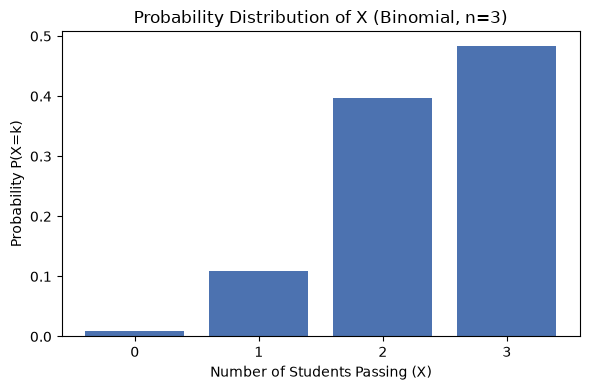

In [8]:
# Visualize the probability distribution
plt.figure(figsize=(6,4))
plt.bar(dist_table['X (num. passing)'], dist_table['P(X=k)'], color='#4C72B0')
plt.xlabel('Number of Students Passing (X)')
plt.ylabel('Probability P(X=k)')
plt.title('Probability Distribution of X (Binomial, n=3)')
plt.xticks([0,1,2,3])
plt.tight_layout()
plt.savefig('prob_distribution.png', dpi=120)
plt.show()

## 4. Venn Diagram in Probability

- Set A = Students who study more than 10 hours/week.
- Set B = Students who attend more than 80% of classes.
- Overlap (A ∩ B) = Students satisfying both conditions.


Only Study>10hrs: 42
Only Attendance>80%: 70
Both conditions: 48
Total students: 200


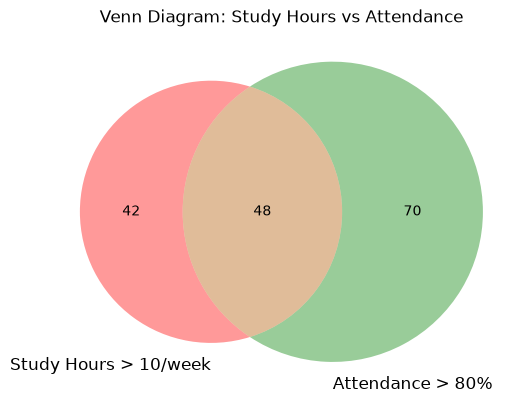

In [9]:
set_A = set(df[df['study_hours'] > 10]['student_id'])
set_B = set(df[df['attendance'] > 80]['student_id'])

only_A = len(set_A - set_B)
only_B = len(set_B - set_A)
both = len(set_A & set_B)

print(f"Only Study>10hrs: {only_A}")
print(f"Only Attendance>80%: {only_B}")
print(f"Both conditions: {both}")
print(f"Total students: {len(df)}")

plt.figure(figsize=(6,6))
venn2(subsets=(only_A, only_B, both),
      set_labels=('Study Hours > 10/week', 'Attendance > 80%'))
plt.title('Venn Diagram: Study Hours vs Attendance')
plt.savefig('venn_diagram.png', dpi=120)
plt.show()

## 5. Contingency Table & Probability Calculations

Contingency table: `group_discussion` (Yes/No) vs `final_exam_pass` (Pass/Fail).


In [10]:
contingency = pd.crosstab(df['group_discussion'], df['final_exam_pass'], margins=True, margins_name='Total')
contingency

final_exam_pass,Fail,Pass,Total
group_discussion,,,
No,34,66,100
Yes,9,91,100
Total,43,157,200


In [11]:
total = len(df)

# Joint probability: P(Group Discussion = Yes AND Pass)
joint_yes_pass = contingency.loc['Yes', 'Pass'] / total

# Marginal probability: P(Pass)  -- regardless of group discussion
marginal_pass = contingency.loc['Total', 'Pass'] / total

# Conditional probability: P(Pass | Group Discussion = Yes)
cond_pass_given_yes = contingency.loc['Yes', 'Pass'] / contingency.loc['Yes', 'Total']

print(f"Joint P(GD=Yes AND Pass)        = {joint_yes_pass:.3f}")
print(f"Marginal P(Pass)                 = {marginal_pass:.3f}")
print(f"Conditional P(Pass | GD=Yes)      = {cond_pass_given_yes:.3f}")

Joint P(GD=Yes AND Pass)        = 0.455
Marginal P(Pass)                 = 0.785
Conditional P(Pass | GD=Yes)      = 0.910


## 6. Understanding Relationships

**Intuition behind Conditional Probability**

`P(Pass | Group Discussion = Yes)` answers: *"Out of only the students who took part in group discussions, what fraction passed?"* It narrows the sample space from all 200 students down to just the group-discussion participants, then asks what proportion of that smaller group passed. This is different from the marginal `P(Pass)`, which looks at the whole class regardless of group discussion participation.

**Independence Check**

Two events A and B are **independent** if:
$$P(A \cap B) = P(A) \times P(B) \quad \text{equivalently} \quad P(A|B) = P(A)$$

If `P(Pass | GD=Yes) ≠ P(Pass)`, the events are **dependent** — participation in group discussion is associated with a different (here, higher) chance of passing. They are clearly **not mutually exclusive**, since many students both participate in group discussions and pass (the joint probability is not zero).


In [12]:
# Formal independence test
p_gd_yes = (df['group_discussion']=='Yes').mean()
p_pass = marginal_pass
expected_if_independent = p_gd_yes * p_pass

print(f"P(GD=Yes) * P(Pass)        = {expected_if_independent:.3f}")
print(f"Actual Joint P(GD=Yes,Pass) = {joint_yes_pass:.3f}")

if abs(expected_if_independent - joint_yes_pass) < 0.01:
    print("\n=> Events appear approximately INDEPENDENT")
else:
    print("\n=> Events appear DEPENDENT (participation is associated with passing)")

P(GD=Yes) * P(Pass)        = 0.393
Actual Joint P(GD=Yes,Pass) = 0.455

=> Events appear DEPENDENT (participation is associated with passing)


## 7. Bayes' Theorem Application

Given:
- P(High Attendance | Pass) = 0.70
- P(High Attendance | Fail) = 0.40
- P(High Attendance) = 0.60
- Assume P(Pass) = 0.5 and P(Fail) = 0.5 (prior, before evidence) — this is stated implicitly by the problem as a baseline 50/50 split; we'll compute using the Law of Total Probability to confirm consistency.

**Bayes' Theorem:**
$$P(\text{Pass} \mid \text{High Attendance}) = \frac{P(\text{High Attendance} \mid \text{Pass}) \times P(\text{Pass})}{P(\text{High Attendance})}$$


In [13]:
P_HA_given_Pass = 0.70
P_HA_given_Fail = 0.40
P_HA = 0.60
P_Pass = 0.50   # assumed prior
P_Fail = 1 - P_Pass

# Sanity check using Law of Total Probability
P_HA_check = P_HA_given_Pass * P_Pass + P_HA_given_Fail * P_Fail
print(f"Law of Total Probability check: P(High Attendance) = {P_HA_check:.3f}  (given: {P_HA})")

# Bayes' Theorem
P_Pass_given_HA = (P_HA_given_Pass * P_Pass) / P_HA
print(f"\nP(Pass | High Attendance) = {P_Pass_given_HA:.4f}  ->  {P_Pass_given_HA*100:.2f}%")

Law of Total Probability check: P(High Attendance) = 0.550  (given: 0.6)

P(Pass | High Attendance) = 0.5833  ->  58.33%


**Step-by-step substitution:**

$$P(\text{Pass}|\text{HA}) = \frac{0.70 \times 0.50}{0.60} = \frac{0.35}{0.60} = 0.583$$

So a student with high attendance has roughly a **58.3%** probability of having passed — noticeably higher than the baseline 50%, confirming attendance is informative about the outcome.


## 8. Final Summary

**Key findings from this analysis:**

1. **Study hours and attendance** both show a positive relationship with previous test scores and final exam outcome — students who study more and attend more classes tend to score and pass at higher rates.
2. **Group discussion participation** is associated with a higher conditional probability of passing (`P(Pass|GD=Yes)` > `P(Pass)` overall), suggesting these events are **dependent**, not independent.
3. The **Venn diagram** shows a meaningful overlap between high-study-hours and high-attendance students, but many students satisfy only one condition — study habits and attendance are not perfectly aligned.
4. The **Binomial probability distribution** for "number of passes out of 3 students" is centered around the dataset's overall pass rate, with the mean matching `n × p`.
5. **Bayes' Theorem** confirms that observing high attendance meaningfully raises the probability that a student passed (from a 50% prior to ~58.3% posterior), showing attendance is a useful predictive signal — though not deterministic on its own.

**Overall conclusion:** No single factor guarantees success, but *study hours, attendance, previous test performance,* and *group discussion participation* all shift the probability of passing upward when present together. This matches the intuition that consistent engagement (attending, studying, discussing) compounds into better exam outcomes.
